# Volatility Swap vs Variance Swap — Jewitt Chapter 31 스타일 시각화

이 노트북은 다음 세 가지 관점을 분리해서 보여준다.

1. **Book definition**: realized variance, payoff, notional convention.
2. **Payoff-transform view**: 같은 accrued variance를 쓰더라도 `var swap = V`, `vol swap = sqrt(V)`라서 variance-equivalent exposure가 다르다.
3. **Jewitt-style Greek view**: fixing 이후 previous fixing을 중심으로 value, delta, gamma, vega profile이 어떻게 달라지는지 본다.

주의할 점:

- 모든 volatility 입력은 코드 내부에서 **decimal**로 쓴다. 예: `12% = 0.12`.
- `N_VOL_ABS`는 decimal volatility 1.00, 즉 100 vol points 기준 notional이다.
- 시장에서 말하는 `USD 10k vega`는 보통 **1 vol point = 1% vol move**당 USD 10k이므로, 코드에서는 `10_000 / 0.01 = 1_000_000`으로 변환한다.
- `variance sensitivity`인 `dP/d(sigma^2)`와 market vega인 `dP/dsigma`를 분리해서 그린다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

%matplotlib inline

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.formatter.useoffset"] = False

## 1. Parameters

Jewitt 예시와 맞추기 위해 기본값은 **USD 10k vega, 12% strike, 252 fixing days**로 둔다.

- `K_VOL = 0.12`
- `VEGA_NOTIONAL_PER_1PCT = 10_000`
- `N_VOL_ABS = 1_000_000`
- `N_VAR = N_VOL_ABS / (2 K_VOL)`

`N_VAR = N_VOL / (2K)`는 strike 근처에서 vol swap payoff와 var swap payoff의 tangent를 맞추는 convention이다.

In [2]:
@dataclass(frozen=True)
class SwapConfig:
    k_vol: float = 0.12                    # 12% volatility strike, decimal
    vega_notional_per_1pct: float = 10_000 # USD per 1 vol point
    n_days: int = 252                      # number of log returns in the contract
    annualization: int = 252               # FX convention in the book
    true_path_vol: float = 0.18            # simulated path realized vol input
    seed: int = 42

cfg = SwapConfig()

# Convert USD per 1 vol point into USD per absolute decimal volatility unit.
# Example: USD 10k per 1% move => USD 1,000,000 per 100% move.
N_VOL_ABS = cfg.vega_notional_per_1pct / 0.01
N_VAR = N_VOL_ABS / (2 * cfg.k_vol)

print(f"K_VOL                  = {cfg.k_vol:.2%}")
print(f"Vol notional per 1%    = USD {cfg.vega_notional_per_1pct:,.0f}")
print(f"N_VOL_ABS              = USD {N_VOL_ABS:,.0f} per 100 vol points")
print(f"N_VAR                  = USD {N_VAR:,.0f} per variance unit")
print(f"1 vol point tangent check near strike: approximately USD {cfg.vega_notional_per_1pct:,.0f}")

K_VOL                  = 12.00%
Vol notional per 1%    = USD 10,000
N_VOL_ABS              = USD 1,000,000 per 100 vol points
N_VAR                  = USD 4,166,667 per variance unit
1 vol point tangent check near strike: approximately USD 10,000


## 2. Core formulas

Daily fixing log return:

\[
a_i=\ln\left(\frac{S_i}{S_{i-1}}\right)
\]

Realized variance:

\[
V=\frac{252}{N}\sum_{i=1}^{N}a_i^2
\]

Payoffs:

\[
\Pi_{vol}=N_{vol}\left(\sqrt{V}-K_{vol}\right)
\]

\[
\Pi_{var}=N_{var}\left(V-K_{vol}^2\right)
\]

In [3]:
def realized_variance_from_log_returns(log_returns, annualization=252):
    """Annualized realized variance from log returns."""
    log_returns = np.asarray(log_returns, dtype=float)
    if log_returns.size == 0:
        return np.nan
    return annualization / log_returns.size * np.sum(log_returns ** 2)


def vol_swap_payoff(realized_vol, k_vol=cfg.k_vol, n_vol_abs=N_VOL_ABS):
    """Vol swap payoff using decimal realized volatility."""
    realized_vol = np.asarray(realized_vol, dtype=float)
    return n_vol_abs * (realized_vol - k_vol)


def var_swap_payoff(realized_vol, k_vol=cfg.k_vol, n_var=N_VAR):
    """Var swap payoff using decimal realized volatility."""
    realized_vol = np.asarray(realized_vol, dtype=float)
    return n_var * (realized_vol ** 2 - k_vol ** 2)


def expected_terminal_variance(t_frac, realized_var_so_far, forward_vol):
    """
    Expected terminal realized variance under a simple accrued + remaining-forward-variance split.

    t_frac               : fraction of fixings already realized, in [0, 1]
    realized_var_so_far  : annualized realized variance over elapsed fixings
    forward_vol          : current forward/fair volatility for the remaining part, decimal
    """
    w_remain = 1.0 - t_frac
    return t_frac * realized_var_so_far + w_remain * forward_vol ** 2


def local_variance_and_vega_exposures(t_frac, realized_var_so_far, forward_vol_grid,
                                      n_vol_abs=N_VOL_ABS, n_var=N_VAR):
    """
    Returns two different exposure definitions:

    1) variance sensitivity: dP / d(forward variance)
    2) market vega: dP / d(forward volatility), reported later per 1 vol point by multiplying by 0.01

    Vol swap uses the first-order approximation:
        P_vol ≈ N_vol * (sqrt(E[V_T]) - K)
    This is for Greek intuition. Exact pricing uses E[sqrt(V_T)], not sqrt(E[V_T]).
    """
    forward_vol_grid = np.asarray(forward_vol_grid, dtype=float)
    w_remain = 1.0 - t_frac
    vbar = expected_terminal_variance(t_frac, realized_var_so_far, forward_vol_grid)
    vbar = np.maximum(vbar, 1e-14)

    # Sensitivity to remaining forward variance F_var = sigma_fwd^2
    d_var_d_fvar = np.full_like(forward_vol_grid, n_var * w_remain)
    d_vol_d_fvar = n_vol_abs * w_remain / (2.0 * np.sqrt(vbar))

    # Sensitivity to remaining forward volatility sigma_fwd
    d_var_d_sigma = 2.0 * n_var * w_remain * forward_vol_grid
    d_vol_d_sigma = n_vol_abs * w_remain * forward_vol_grid / np.sqrt(vbar)

    return pd.DataFrame({
        "forward_vol": forward_vol_grid,
        "Vbar": vbar,
        "var_dP_dFvar": d_var_d_fvar,
        "vol_dP_dFvar": d_vol_d_fvar,
        "var_vega_abs": d_var_d_sigma,
        "vol_vega_abs": d_vol_d_sigma,
        "var_vega_per_1pct": 0.01 * d_var_d_sigma,
        "vol_vega_per_1pct": 0.01 * d_vol_d_sigma,
    })

## 3. Payoff at maturity: same strike tangent, different curvature

x축을 realized volatility로 두면:

- Vol swap payoff는 realized volatility에 대해 직선.
- Var swap payoff는 realized volatility에 대해 볼록한 포물선.
- `N_VAR = N_VOL / (2K)`로 잡으면 strike 근처에서 두 payoff의 tangent가 맞는다.

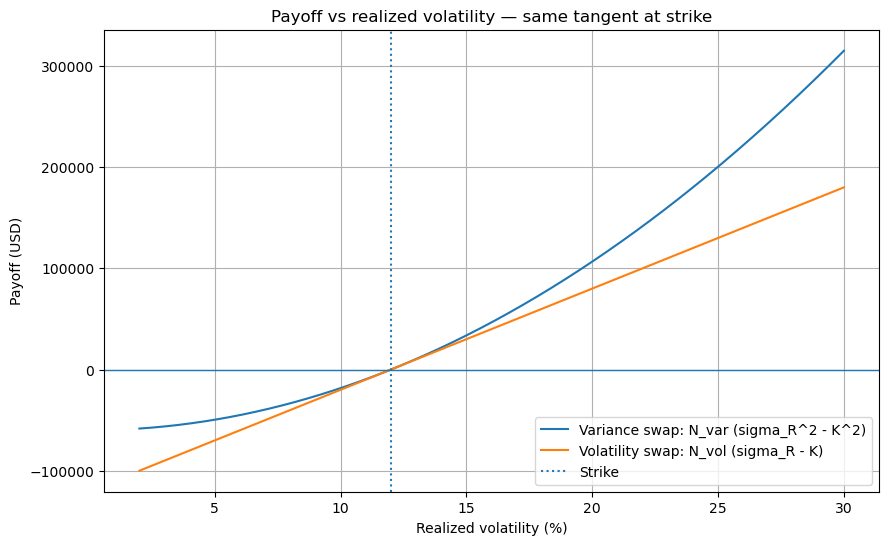

In [4]:
sigma_grid = np.linspace(0.02, 0.30, 600)

plt.figure()
plt.plot(sigma_grid * 100, var_swap_payoff(sigma_grid), label="Variance swap: N_var (sigma_R^2 - K^2)")
plt.plot(sigma_grid * 100, vol_swap_payoff(sigma_grid), label="Volatility swap: N_vol (sigma_R - K)")
plt.axvline(cfg.k_vol * 100, linestyle=":", linewidth=1.5, label="Strike")
plt.axhline(0.0, linewidth=1)
plt.title("Payoff vs realized volatility — same tangent at strike")
plt.xlabel("Realized volatility (%)")
plt.ylabel("Payoff (USD)")
plt.legend()
plt.show()

## 4. Variance sensitivity vs market vega

여기서 가장 중요한 구분:

- `dP/d(sigma^2)` = variance sensitivity, 또는 local variance-equivalent exposure.
- `dP/dsigma` = market vega.

책의 “variance swap vega is linear in implied volatility”는 두 번째 의미, 즉 `dP/dsigma` 기준이다. 반면 “var swap의 variance exposure가 constant”라고 할 때는 첫 번째 의미다.

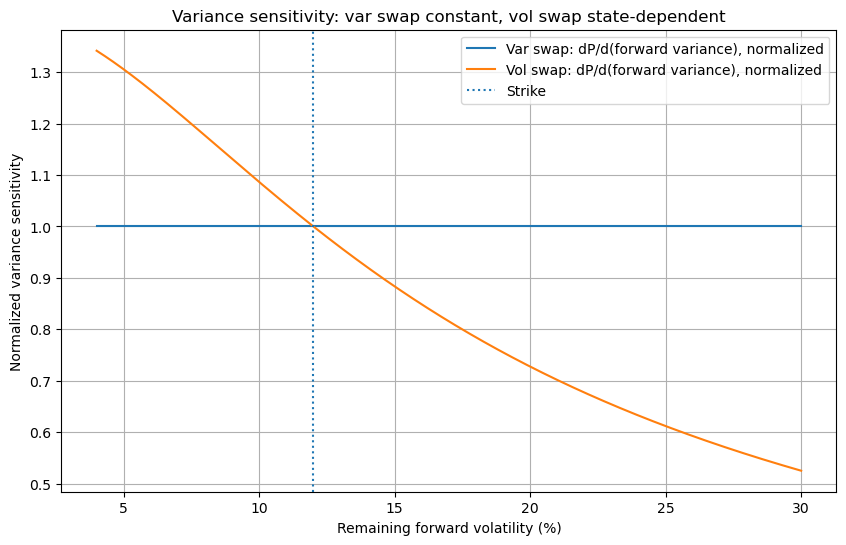

In [5]:
# Half-life example: half the fixings are already known, and accrued realized vol is at strike.
t_frac = 0.50
accrued_vol = cfg.k_vol
accrued_var = accrued_vol ** 2
forward_vol_grid = np.linspace(0.04, 0.30, 600)

expo = local_variance_and_vega_exposures(t_frac, accrued_var, forward_vol_grid)

# Normalize variance sensitivity by the var swap level, so var swap line is exactly 1.
normalizer = N_VAR * (1.0 - t_frac)

plt.figure()
plt.plot(expo["forward_vol"] * 100,
         expo["var_dP_dFvar"] / normalizer,
         label="Var swap: dP/d(forward variance), normalized")
plt.plot(expo["forward_vol"] * 100,
         expo["vol_dP_dFvar"] / normalizer,
         label="Vol swap: dP/d(forward variance), normalized")
plt.axvline(cfg.k_vol * 100, linestyle=":", linewidth=1.5, label="Strike")
plt.title("Variance sensitivity: var swap constant, vol swap state-dependent")
plt.xlabel("Remaining forward volatility (%)")
plt.ylabel("Normalized variance sensitivity")
plt.legend()
plt.show()

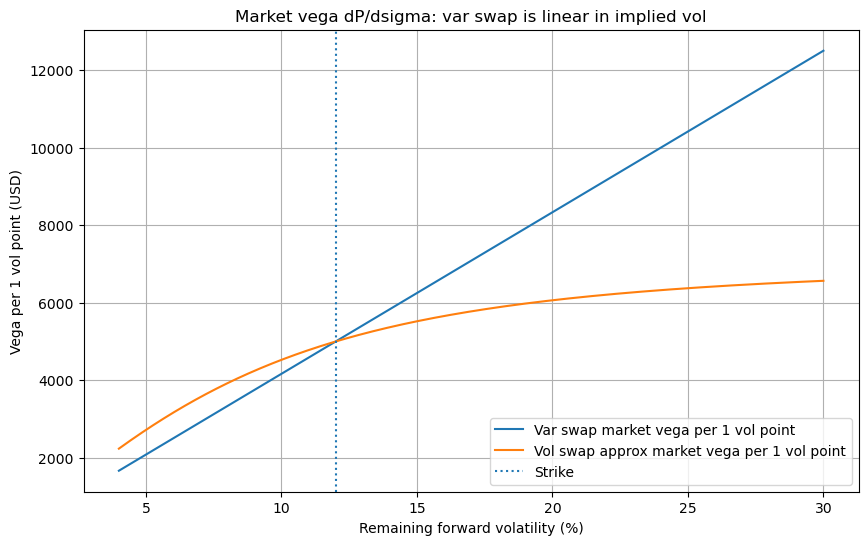

In [6]:
plt.figure()
plt.plot(expo["forward_vol"] * 100,
         expo["var_vega_per_1pct"],
         label="Var swap market vega per 1 vol point")
plt.plot(expo["forward_vol"] * 100,
         expo["vol_vega_per_1pct"],
         label="Vol swap approx market vega per 1 vol point")
plt.axvline(cfg.k_vol * 100, linestyle=":", linewidth=1.5, label="Strike")
plt.title("Market vega dP/dsigma: var swap is linear in implied vol")
plt.xlabel("Remaining forward volatility (%)")
plt.ylabel("Vega per 1 vol point (USD)")
plt.legend()
plt.show()

In [7]:
# Numerical check at selected vol levels.
check_vols = np.array([0.08, 0.12, 0.20, 0.30])
check = local_variance_and_vega_exposures(t_frac, accrued_var, check_vols)
check[[
    "forward_vol", "Vbar", "var_dP_dFvar", "vol_dP_dFvar", 
    "var_vega_per_1pct", "vol_vega_per_1pct"
]].assign(
    forward_vol_pct=lambda df: 100 * df["forward_vol"],
    Vbar_vol_pct=lambda df: 100 * np.sqrt(df["Vbar"]),
)[[
    "forward_vol_pct", "Vbar_vol_pct", "var_dP_dFvar", "vol_dP_dFvar",
    "var_vega_per_1pct", "vol_vega_per_1pct"
]].round(2)

,forward_vol_pct,Vbar_vol_pct,var_dP_dFvar,vol_dP_dFvar,var_vega_per_1pct,vol_vega_per_1pct
0,8.0,10.20,2083333.33,2451451.69,3333.33,3922.32
1,12.0,12.00,2083333.33,2083333.33,5000.00,5000.00
2,20.0,16.49,2083333.33,1515847.66,8333.33,6063.39
3,30.0,22.85,2083333.33,1094220.27,12500.00,6565.32


## 5. Effective variance notional

Vol swap을 local하게 var swap으로 hedge한다고 보면:

\[
\frac{\partial}{\partial V}\sqrt{V}=\frac{1}{2\sqrt{V}}
\]

따라서 vol swap의 local variance-equivalent notional은

\[
N_{var}^{eff}=\frac{N_{vol}}{2\sqrt{\bar V_t}}
\]

이고, var swap의 variance notional은 그냥 constant다.

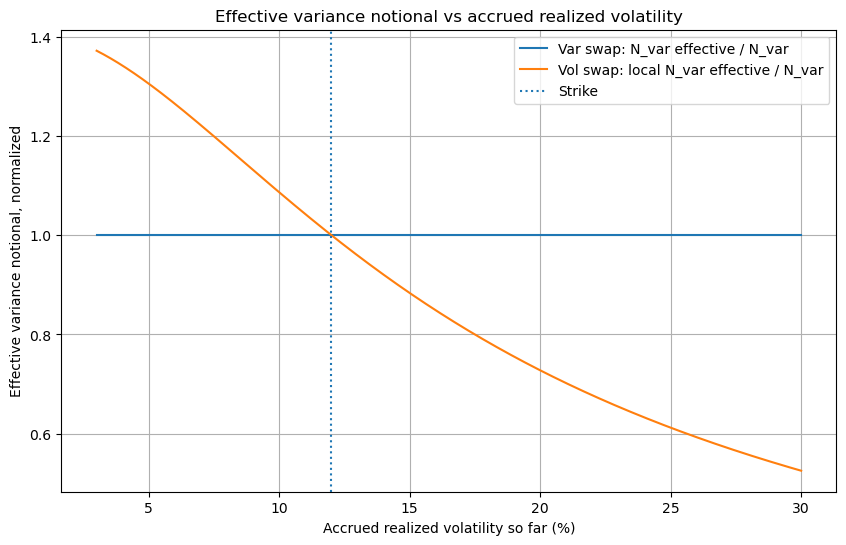

In [8]:
accrued_vol_grid = np.linspace(0.03, 0.30, 600)
forward_vol_assumption = cfg.k_vol
vbar_by_accrued = expected_terminal_variance(t_frac, accrued_vol_grid ** 2, forward_vol_assumption)

nvar_eff_var = np.full_like(accrued_vol_grid, N_VAR)
nvar_eff_vol = N_VOL_ABS / (2.0 * np.sqrt(vbar_by_accrued))

plt.figure()
plt.plot(accrued_vol_grid * 100, nvar_eff_var / N_VAR, label="Var swap: N_var effective / N_var")
plt.plot(accrued_vol_grid * 100, nvar_eff_vol / N_VAR, label="Vol swap: local N_var effective / N_var")
plt.axvline(cfg.k_vol * 100, linestyle=":", linewidth=1.5, label="Strike")
plt.title("Effective variance notional vs accrued realized volatility")
plt.xlabel("Accrued realized volatility so far (%)")
plt.ylabel("Effective variance notional, normalized")
plt.legend()
plt.show()

## 6. One simulated path: same accrual, different exposure transform

아래는 하나의 spot path에서 daily log return을 만들고, 같은 accumulated realized variance를 var swap과 vol swap에 동시에 넣는다.

- Var swap: effective variance notional이 flat.
- Vol swap: `1 / sqrt(Vbar)` factor 때문에 realized variance가 쌓이는 상태에 따라 effective variance notional이 움직인다.

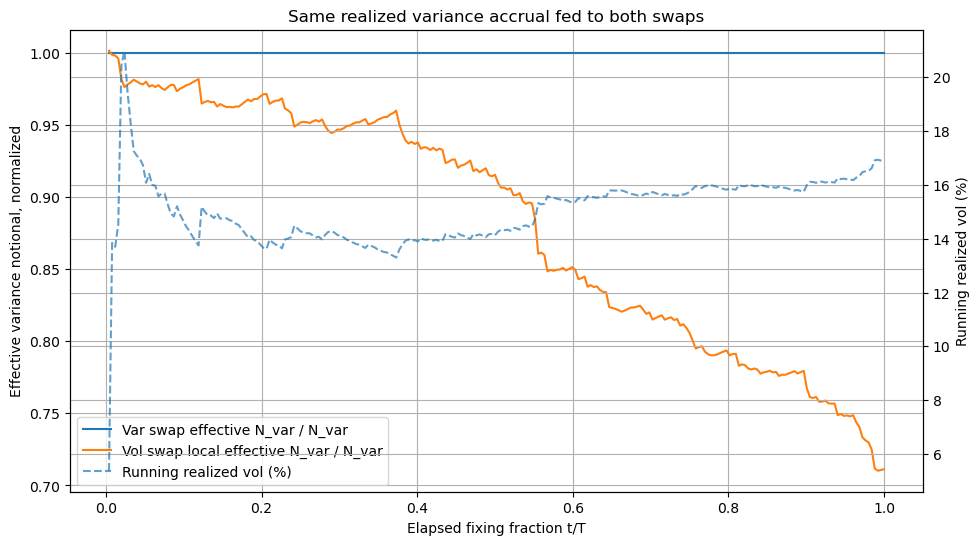

In [9]:
rng = np.random.default_rng(cfg.seed)
n = cfg.n_days
dt = 1.0 / cfg.annualization

# GBM log returns. Drift is not the focus; included only for a realistic-looking path.
log_returns = (-0.5 * cfg.true_path_vol ** 2) * dt + cfg.true_path_vol * np.sqrt(dt) * rng.standard_normal(n)
spot_path = 100.0 * np.exp(np.r_[0.0, np.cumsum(log_returns)])

steps = np.arange(1, n + 1)
t_frac_path = steps / n
cum_sq_returns = np.cumsum(log_returns ** 2)
rv_so_far = cfg.annualization / steps * cum_sq_returns
running_realized_vol = np.sqrt(rv_so_far)

# Assume the remaining forward vol is fixed at K_VOL for this diagnostic.
vbar_path = t_frac_path * rv_so_far + (1.0 - t_frac_path) * cfg.k_vol ** 2
nvar_eff_var_path = np.full_like(vbar_path, N_VAR)
nvar_eff_vol_path = N_VOL_ABS / (2.0 * np.sqrt(np.maximum(vbar_path, 1e-14)))

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(t_frac_path, nvar_eff_var_path / N_VAR, label="Var swap effective N_var / N_var")
ax1.plot(t_frac_path, nvar_eff_vol_path / N_VAR, label="Vol swap local effective N_var / N_var")
ax1.set_xlabel("Elapsed fixing fraction t/T")
ax1.set_ylabel("Effective variance notional, normalized")
ax1.set_title("Same realized variance accrual fed to both swaps")

ax2 = ax1.twinx()
ax2.plot(t_frac_path, running_realized_vol * 100, linestyle="--", alpha=0.7, label="Running realized vol (%)")
ax2.set_ylabel("Running realized vol (%)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.show()

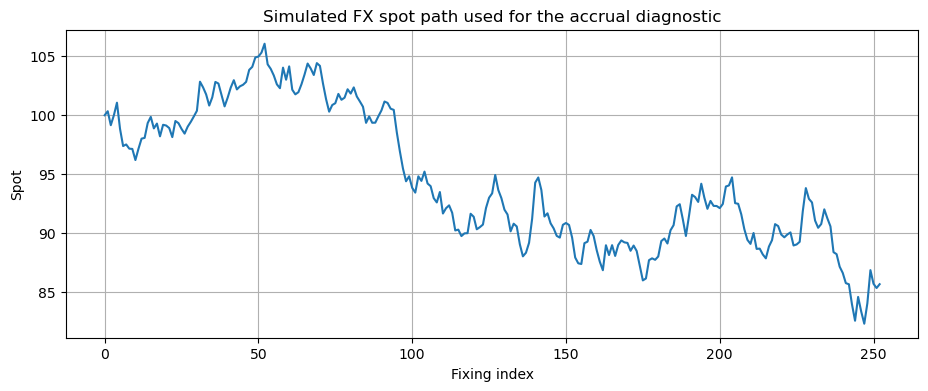

In [10]:
plt.figure(figsize=(11, 4))
plt.plot(np.arange(n + 1), spot_path)
plt.title("Simulated FX spot path used for the accrual diagnostic")
plt.xlabel("Fixing index")
plt.ylabel("Spot")
plt.show()

## 7. Jewitt-style spot-after-fixing Greek profiles

이 섹션은 책의 Exhibit 31.3~31.11에 더 가까운 그림이다.

한 번의 fixing 이후 current spot이 previous fixing에서 얼마나 떨어졌는지를

\[
x=\ln(S/S_{fix})
\]

로 두고, 그 daily log return contribution을 terminal realized variance에 넣는다.

\[
\bar V(x)=\frac{252}{N}x^2 + \frac{N-1}{N}K^2
\]

여기서 delta/gamma는 **log-spot move `x`에 대한 profile**로 그린다. Raw spot delta/gamma가 필요하면 chain rule로 바꿀 수 있다.

- Var swap: value는 `x`에 대해 quadratic, delta는 linear, gamma는 constant.
- Vol swap: `sqrt(Vbar)` 때문에 gamma가 previous fixing 근처에서 peak를 갖고 wings에서 낮아진다.
- Vega: var swap은 spot across에서 flat, vol swap은 previous fixing 근처가 높고 wings에서 낮다.

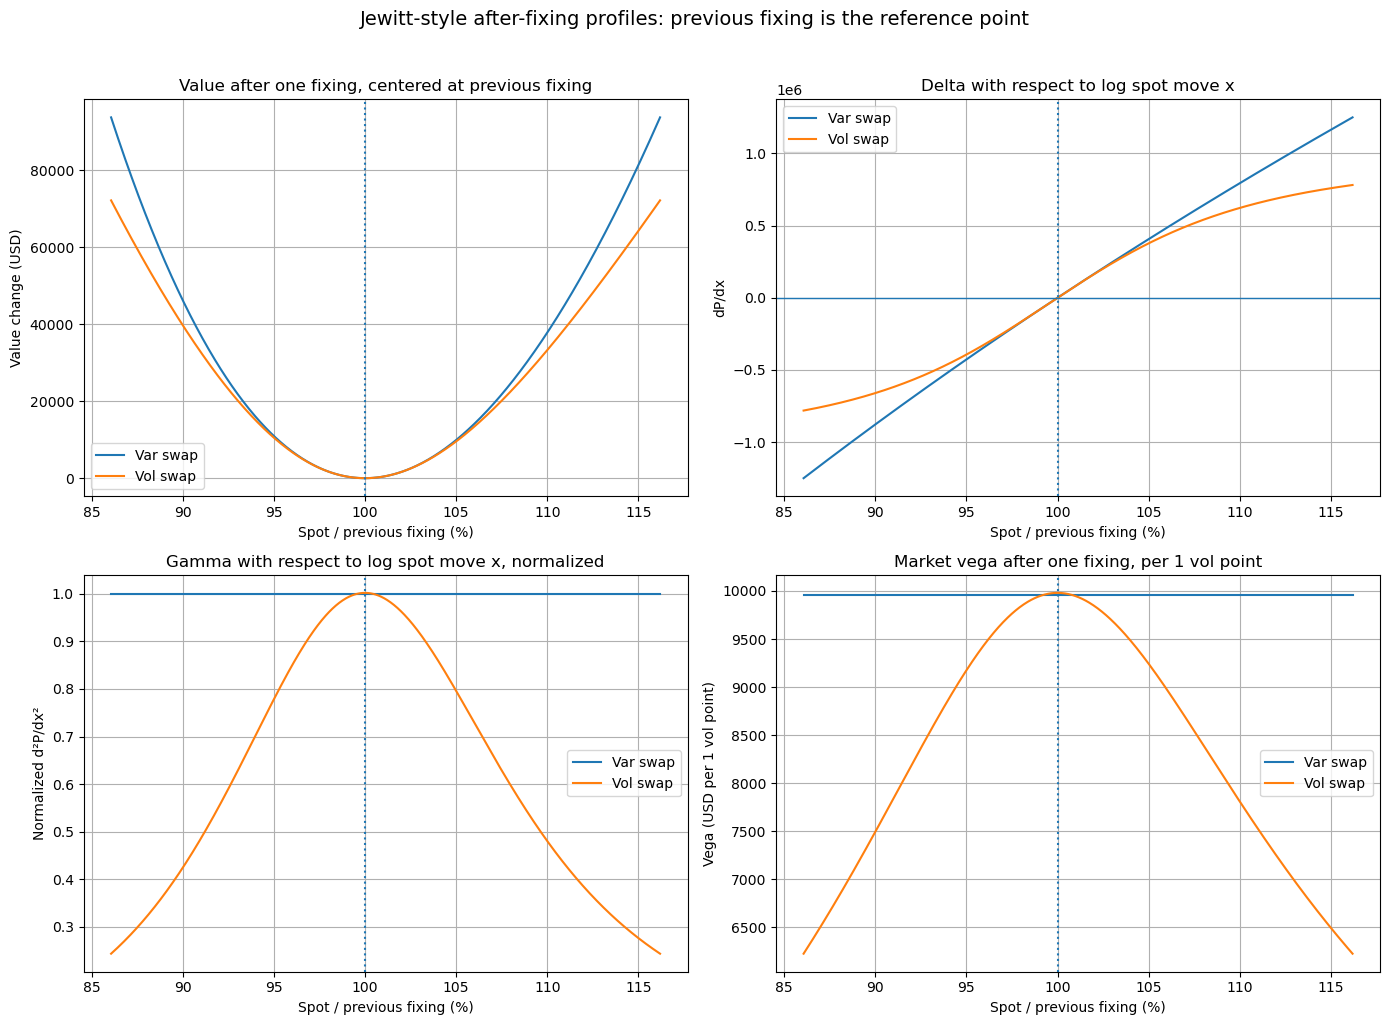

In [11]:
# Log spot move around the previous fixing.
x = np.linspace(-0.15, 0.15, 801)  # roughly +/-15% log move
spot_ratio = np.exp(x)

n_fixed = 1
c_one_fixing = cfg.annualization / cfg.n_days
w_remaining = (cfg.n_days - n_fixed) / cfg.n_days
remaining_var = w_remaining * cfg.k_vol ** 2

vbar_x = remaining_var + c_one_fixing * x ** 2
vbar_x = np.maximum(vbar_x, 1e-14)

# Values, centered at x=0 to isolate the spot-profile shape after fixing.
p_var_x = N_VAR * (vbar_x - cfg.k_vol ** 2)
p_vol_x = N_VOL_ABS * (np.sqrt(vbar_x) - cfg.k_vol)
p_var_x_centered = p_var_x - p_var_x[np.argmin(np.abs(x))]
p_vol_x_centered = p_vol_x - p_vol_x[np.argmin(np.abs(x))]

# Delta and gamma with respect to x = log(S/S_fix).
delta_x_var = 2.0 * N_VAR * c_one_fixing * x
delta_x_vol = N_VOL_ABS * c_one_fixing * x / np.sqrt(vbar_x)

gamma_x_var = np.full_like(x, 2.0 * N_VAR * c_one_fixing)
gamma_x_vol = N_VOL_ABS * c_one_fixing * remaining_var / (vbar_x ** 1.5)

# Market vega for remaining implied vol, per 1 vol point.
vega_var_per_1pct_x = 0.01 * (2.0 * N_VAR * w_remaining * cfg.k_vol) * np.ones_like(x)
vega_vol_per_1pct_x = 0.01 * (N_VOL_ABS * w_remaining * cfg.k_vol / np.sqrt(vbar_x))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(spot_ratio * 100, p_var_x_centered, label="Var swap")
axes[0, 0].plot(spot_ratio * 100, p_vol_x_centered, label="Vol swap")
axes[0, 0].axvline(100, linestyle=":", linewidth=1.5)
axes[0, 0].set_title("Value after one fixing, centered at previous fixing")
axes[0, 0].set_xlabel("Spot / previous fixing (%)")
axes[0, 0].set_ylabel("Value change (USD)")
axes[0, 0].legend()

axes[0, 1].plot(spot_ratio * 100, delta_x_var, label="Var swap")
axes[0, 1].plot(spot_ratio * 100, delta_x_vol, label="Vol swap")
axes[0, 1].axvline(100, linestyle=":", linewidth=1.5)
axes[0, 1].axhline(0, linewidth=1)
axes[0, 1].set_title("Delta with respect to log spot move x")
axes[0, 1].set_xlabel("Spot / previous fixing (%)")
axes[0, 1].set_ylabel("dP/dx")
axes[0, 1].legend()

axes[1, 0].plot(spot_ratio * 100, gamma_x_var / gamma_x_var.max(), label="Var swap")
axes[1, 0].plot(spot_ratio * 100, gamma_x_vol / gamma_x_var.max(), label="Vol swap")
axes[1, 0].axvline(100, linestyle=":", linewidth=1.5)
axes[1, 0].set_title("Gamma with respect to log spot move x, normalized")
axes[1, 0].set_xlabel("Spot / previous fixing (%)")
axes[1, 0].set_ylabel("Normalized d²P/dx²")
axes[1, 0].legend()

axes[1, 1].plot(spot_ratio * 100, vega_var_per_1pct_x, label="Var swap")
axes[1, 1].plot(spot_ratio * 100, vega_vol_per_1pct_x, label="Vol swap")
axes[1, 1].axvline(100, linestyle=":", linewidth=1.5)
axes[1, 1].set_title("Market vega after one fixing, per 1 vol point")
axes[1, 1].set_xlabel("Spot / previous fixing (%)")
axes[1, 1].set_ylabel("Vega (USD per 1 vol point)")
axes[1, 1].legend()

fig.suptitle("Jewitt-style after-fixing profiles: previous fixing is the reference point", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Optional: convert log-spot Greeks into raw spot Greeks

위 그림의 delta/gamma는 `x = ln(S/S_fix)`에 대한 값이다. 실제 raw spot Greek은 다음 chain rule로 변환된다.

\[
\frac{\partial P}{\partial S}=\frac{1}{S}\frac{\partial P}{\partial x}
\]

\[
\frac{\partial^2 P}{\partial S^2}=\frac{1}{S^2}\left(\frac{\partial^2 P}{\partial x^2}-\frac{\partial P}{\partial x}\right)
\]

책의 “delta linear / gamma constant” intuition은 log-return accrual에 자연스러운 `x` 기준에서 가장 깨끗하게 보인다.

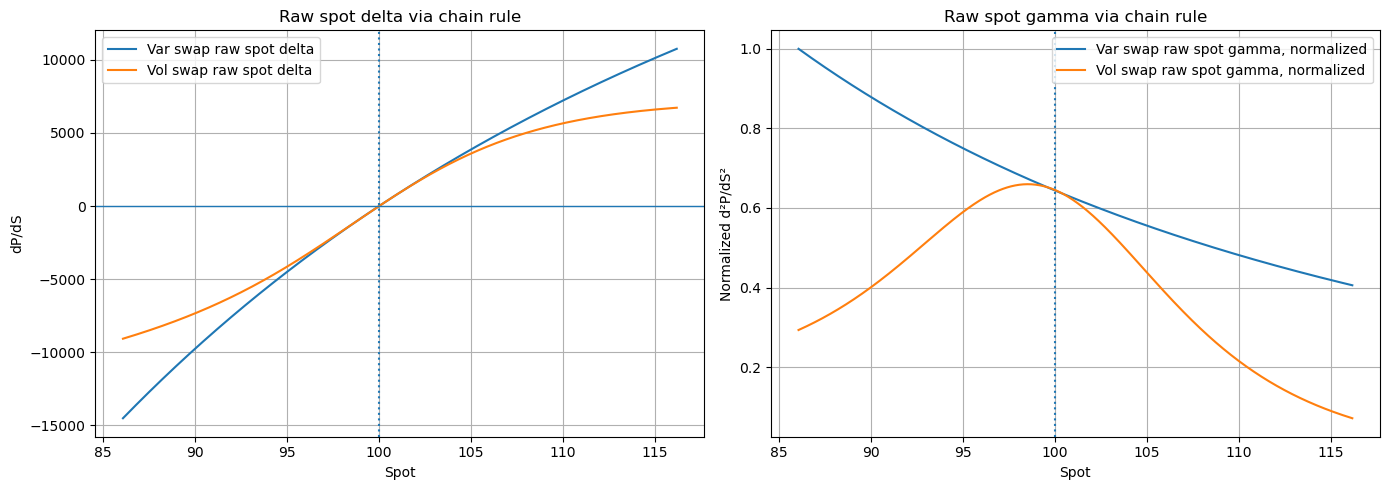

In [12]:
S_fix = 100.0
S = S_fix * spot_ratio

raw_delta_var = delta_x_var / S
raw_delta_vol = delta_x_vol / S
raw_gamma_var = (gamma_x_var - delta_x_var) / (S ** 2)
raw_gamma_vol = (gamma_x_vol - delta_x_vol) / (S ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(S, raw_delta_var, label="Var swap raw spot delta")
axes[0].plot(S, raw_delta_vol, label="Vol swap raw spot delta")
axes[0].axvline(S_fix, linestyle=":", linewidth=1.5)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Raw spot delta via chain rule")
axes[0].set_xlabel("Spot")
axes[0].set_ylabel("dP/dS")
axes[0].legend()

axes[1].plot(S, raw_gamma_var / np.nanmax(raw_gamma_var), label="Var swap raw spot gamma, normalized")
axes[1].plot(S, raw_gamma_vol / np.nanmax(raw_gamma_var), label="Vol swap raw spot gamma, normalized")
axes[1].axvline(S_fix, linestyle=":", linewidth=1.5)
axes[1].set_title("Raw spot gamma via chain rule")
axes[1].set_xlabel("Spot")
axes[1].set_ylabel("Normalized d²P/dS²")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Convexity adjustment intuition: `E[sqrt(V)]` vs `sqrt(E[V])`

Vol swap의 정확한 pricing object는

\[
E[\sqrt{V_T}]
\]

이지

\[
\sqrt{E[V_T]}
\]

가 아니다. `sqrt`는 concave function이므로 Jensen inequality에 의해 일반적으로

\[
E[\sqrt{V_T}] < \sqrt{E[V_T]}.
\]

아래는 `V_T`가 같은 mean을 가진 lognormal random variable일 때, variance dispersion이 커질수록 convexity adjustment가 커지는 모습을 보여준다.

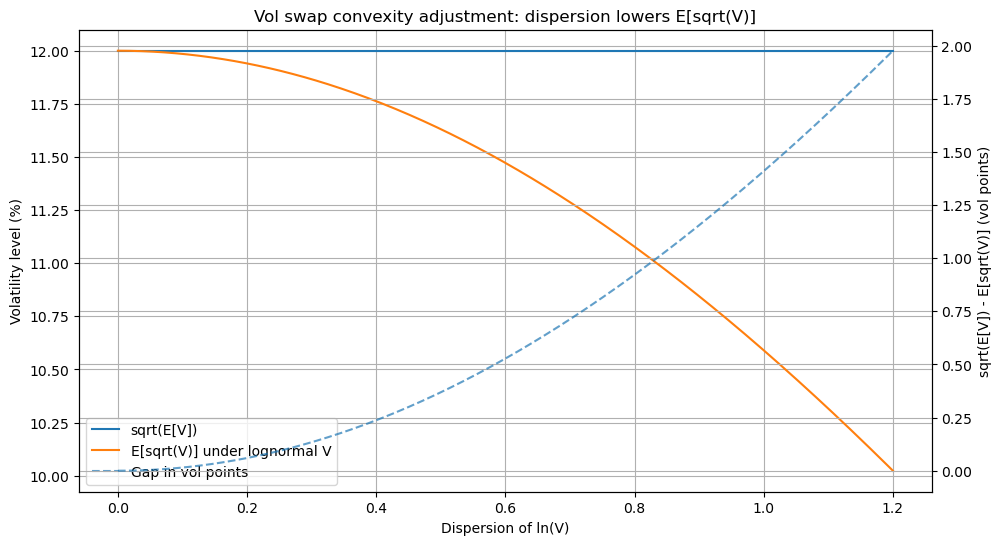

In [13]:
mean_var = cfg.k_vol ** 2
log_var_dispersion = np.linspace(0.0, 1.2, 400)  # std dev of ln(V)

sqrt_E_var = np.sqrt(mean_var) * np.ones_like(log_var_dispersion)
# If V is lognormal with E[V]=m and log-variance s^2, E[sqrt(V)] = sqrt(m) * exp(-s^2/8)
E_sqrt_var = np.sqrt(mean_var) * np.exp(-(log_var_dispersion ** 2) / 8.0)
convexity_gap_vol_points = (sqrt_E_var - E_sqrt_var) * 100

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(log_var_dispersion, sqrt_E_var * 100, label="sqrt(E[V])")
ax1.plot(log_var_dispersion, E_sqrt_var * 100, label="E[sqrt(V)] under lognormal V")
ax1.set_xlabel("Dispersion of ln(V)")
ax1.set_ylabel("Volatility level (%)")
ax1.set_title("Vol swap convexity adjustment: dispersion lowers E[sqrt(V)]")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(log_var_dispersion, convexity_gap_vol_points, linestyle="--", alpha=0.7, label="Gap in vol points")
ax2.set_ylabel("sqrt(E[V]) - E[sqrt(V)] (vol points)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.show()

## 9. Takeaways

- 같은 daily fixing accrual을 써도 payoff transform이 다르면 Greeks가 달라진다.
- Var swap은 `V`에 선형이므로 variance sensitivity가 constant다.
- 책의 market vega 기준으로는 var swap vega가 implied volatility에 linear다.
- Vol swap은 `sqrt(V)` 때문에 local variance hedge ratio가 `1 / (2 sqrt(V))`로 state-dependent다.
- Jewitt-style spot-after-fixing view에서는 vol swap의 gamma/vega가 previous fixing 주변에 집중되고, variance swap은 strikeless gamma/vega intuition을 갖는다.
- 정확한 vol swap pricing은 `sqrt(E[V])`가 아니라 `E[sqrt(V)]`를 필요로 한다.